# Preparation

📘 1. Import the libraries Numerical Python and Panel Data.

In [6]:
import numpy as np
import pandas as pd

📘 2. Import the dataset contained in the path.

🟠 The headers of the dataframe are in the first column.

<details><summary>Solution</summary>

```python
df = pd.read_csv(path, header = 0)
df.head()
```

</details>

In [7]:
df = pd.read_csv("1_Data/df_nomiss.csv", header = 0)

cols_float = ["bore", "stroke", "price", "peak-rpm","horsepower"]
cols_int = ["normalized-losses"]

df[cols_float] = df[cols_float].astype('float')
df[cols_int] = df[cols_int].astype('int')

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


📘 3. Import the visualization packages `matplotlib.pyplot` as `plt`, and `seaborn` as `sns`.


<details><summary>🤓 Why `.pyplot`? </summary>

`matplotlib` is a big library, and `pyplot` is a specific module inside it that provides plotting commands.

Using just:
```python
import matplotlib
```

would not give you `plot()`, `hist()`, etc. You would need to access deeper parts of the library manually, which is tedious.

</details>

<details><summary>🤓 `matplotlib` vs `seaborn`? </summary>

| Feature           | Matplotlib | Seaborn    |
| ----------------- | ---------- | ---------- |
| Level             | Low-level  | High-level |
| Defaults          | Plain      | Stylish    |
| DataFrame support | Manual     | Built-in   |
| Statistical plots | Basic      | Excellent  |
| Custom control    | Very high  | Medium     |


</details>


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

📘 4. Write the jupyter notebook line to avoid writting `plt.show()`.

<details><summary>Solution</summary>

```python
%matplotlib inline
```

🟠 `%matplotlib` inline tells Jupyter to automatically display `matplotlib` plots, so you usually don’t need `plt.show()` in notebooks, but `plt.show()` is still required in regular Python scripts.

</details>

In [2]:
%matplotlib inline

# Choosing the right visualization

📘 5. List the data types for each column

<details><summary>Solution</summary>

```python
df.dtypes
```

</details>

In [8]:
df.dtypes

symboling              int64
normalized-losses      int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

## Numerical variables

📘 6. Display the correlation between all the numeric-type variables.

<details><summary>Solution</summary>

```python
df.corr(numeric_only=True)
```
🤓 This is the pearson correlation index.
</details>



In [9]:
df.corr(numeric_only=True)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.139896,-0.007992,-0.182196,0.075790,0.279719,-0.035527,0.036233,-0.082391
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029800,0.055127,-0.114713,0.217300,0.239544,-0.225016,-0.181877,0.133999
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493203,0.157964,0.250313,0.371250,-0.360233,-0.470606,-0.543304,0.584642
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608941,0.123913,0.159733,0.579731,-0.286035,-0.665192,-0.698142,0.690628
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544879,0.188814,0.189867,0.615006,-0.245852,-0.633531,-0.680635,0.751265
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180327,-0.060822,0.259737,-0.086941,-0.309913,-0.049800,-0.104812,0.135486
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644041,0.167412,0.156433,0.757994,-0.279350,-0.749543,-0.794889,0.834415
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572516,0.205806,0.028889,0.822649,-0.256753,-0.650546,-0.679571,0.872335
bore,-0.139896,-0.029800,0.493203,0.608941,0.544879,0.180327,0.644041,0.572516,1.000000,-0.055390,0.001250,0.566838,-0.267338,-0.582121,-0.591390,0.543154
stroke,-0.007992,0.055127,0.157964,0.123913,0.188814,-0.060822,0.167412,0.205806,-0.055390,1.000000,0.187854,0.097815,-0.063720,-0.034079,-0.034741,0.082267


📘 7. Display the correlation among the variables 'engine-size','highway-mpg','peak-rpm','price'

<details><summary>Solution</summary>

```python
df[['engine-size','price']].corr()
```

Don't specify anything inside `()` as all of them are numeric type.

</details>

In [10]:
df[['engine-size','highway-mpg','peak-rpm','price']].corr()

,engine-size,highway-mpg,peak-rpm,price
engine-size,1.000000,-0.679571,-0.256753,0.872335
highway-mpg,-0.679571,1.000000,-0.058605,-0.704692
peak-rpm,-0.256753,-0.058605,1.000000,-0.101542
price,0.872335,-0.704692,-0.101542,1.000000


📘 8. Display a scatterplot of "engine-size" and "price".

🗣 Hint: use the `sns.regplot()`

<details><summary>Solution</summary>

```python
sns.regplot(x="engine-size", y="price", data=df)
```

</details>

<Axes: xlabel='engine-size', ylabel='price'>

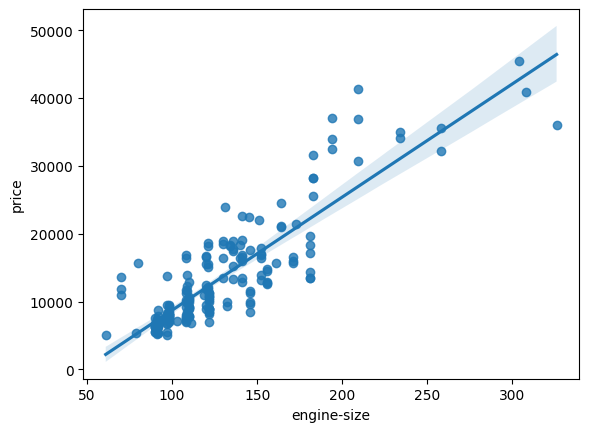

In [11]:
sns.regplot(x="engine-size", y="price", data=df)

📘 9. Display a scatterplot of "engine-size" and "price" again, but setting bounds for `y = (5000,30000)` and `x= (75, 200)`.

<details><summary>Solution</summary>

```python
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(5000,30000)
plt.xlim(75,200)
```

</details>

(75.0, 200.0)

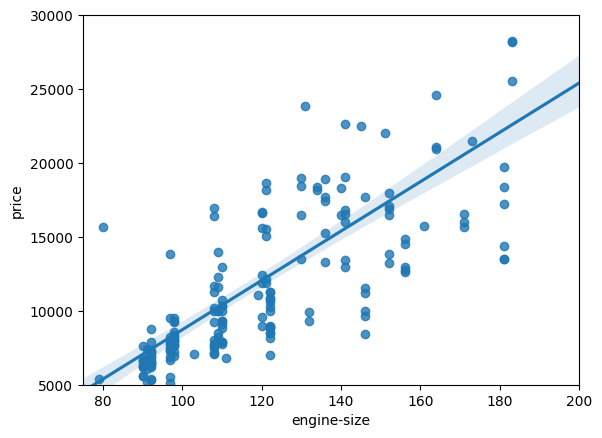

In [12]:
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(5000,30000)
plt.xlim(75,200)

📘 10. Display scatterplots for `highway-mpg`-`price` and `peak-rpm`-`price`

<details><summary>Solution</summary>

One bloc per each code:

```python
# highway-mpg
sns.regplot(x="highway-mpg", y="price", data=df)

# peak-rpm
sns.regplot(x="peak-rpm", y="price", data=df)
```

</details>



<Axes: xlabel='highway-mpg', ylabel='price'>

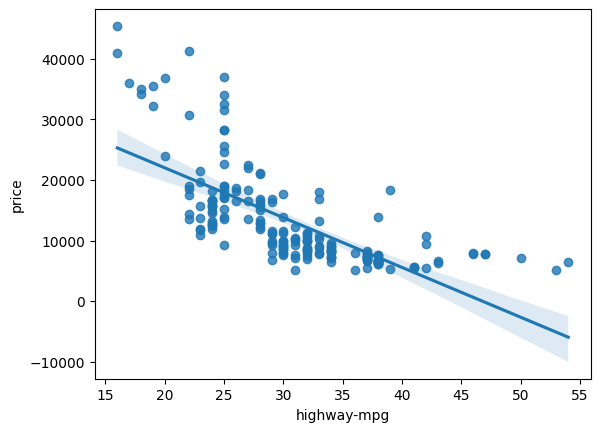

In [13]:
# highway-mpg
sns.regplot(x="highway-mpg", y="price", data=df)

<Axes: xlabel='peak-rpm', ylabel='price'>

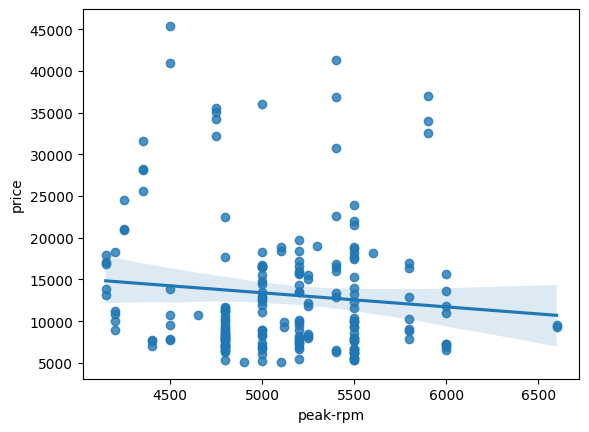

In [14]:
# peak-rpm
sns.regplot(x="peak-rpm", y="price", data=df)

## Categorical variables

📘 11. Display the frquency of values of each of the following variables "body-style", "engine-location" and "drive-wheels".

🟢 the method "value_counts" only works on pandas series, not pandas dataframes

<details><summary>Solution</summary>

```python
print(df['body-style'].value_counts(),"\n"
      ,df['engine-location'].value_counts(),"\n"
      ,df['drive-wheels'].value_counts())
```

</details>

In [15]:
print(df['body-style'].value_counts(),"\n"
      ,df['engine-location'].value_counts(),"\n"
      ,df['drive-wheels'].value_counts())

body-style
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64 
 engine-location
front    198
rear       3
Name: count, dtype: int64 
 drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64


📘 12. Using the dataset `df`, perform the following steps:

1. Select the `'drive-wheels'` column from the DataFrame.

2. Count how many times each drive-wheel type appears.

3. Convert the result into a DataFrame.

4. Rename the column containing the counts to `'value_counts'`.

5. Set the index name to `'drive-wheels'`.

6. Display the final DataFrame.

Your output should show the number of cars for each drive-wheel type (e.g. `fwd`, `rwd`, `4wd`) in a clean, labeled table.

✅ Expected strcutue of the output:

| drive-wheels | value_counts |
| ------------ | ------------ |
| fwd          | 118          |
| rwd          | 75           |
| 4wd          | 8            |

<details><summary>Solution</summary>

```python
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'count': 'value_counts'}, inplace=True)
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts
```

</details>

In [16]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'count': 'value_counts'}, inplace=True)
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


📘 13. Replicate the exercise (12), now for the variables `'engine-location'` and `'body-style'`.

<details><summary>Solution</summary>

One code-block per dataframe

```python
# engine-location
engine_location_counts = df['engine-location'].value_counts().to_frame()
engine_location_counts.rename(columns={'count': 'value_counts'}, inplace=True)
engine_location_counts.index.name = 'engine-location'
engine_location_counts
# body-style
body_style_counts = df['body-style'].value_counts().to_frame()
body_style_counts.rename(columns={'count': 'value_counts'}, inplace=True)
body_style_counts.index.name = 'body-style'
body_style_counts
```

</details>

In [17]:
engine_location_counts = df['engine-location'].value_counts().to_frame()
engine_location_counts.rename(columns={'count': 'value_counts'}, inplace=True)
engine_location_counts.index.name = 'engine-location'
engine_location_counts

,value_counts
engine-location,
front,198
rear,3


In [18]:
body_style_counts = df['body-style'].value_counts().to_frame()
body_style_counts.rename(columns={'count': 'value_counts'}, inplace=True)
body_style_counts.index.name = 'body-style'
body_style_counts

,value_counts
body-style,
sedan,94
hatchback,68
wagon,25
hardtop,8
convertible,6


📘 14. Display three boxplots, where price is the dependent variable and the regressor alternatres among "body-style", "engine-location" and "drive-wheels".


<details><summary>Solution</summary>

One code-block per boxplot

```python
sns.boxplot(x="body-style", y="price", data=df)
sns.boxplot(x="engine-location", y="price", data=df)
sns.boxplot(x="drive-wheels", y="price", data=df)
```

</details>

<Axes: xlabel='body-style', ylabel='price'>

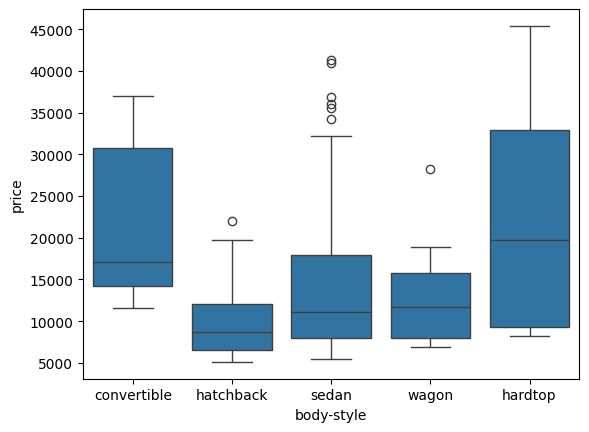

In [19]:
sns.boxplot(x="body-style", y="price", data=df)

<Axes: xlabel='engine-location', ylabel='price'>

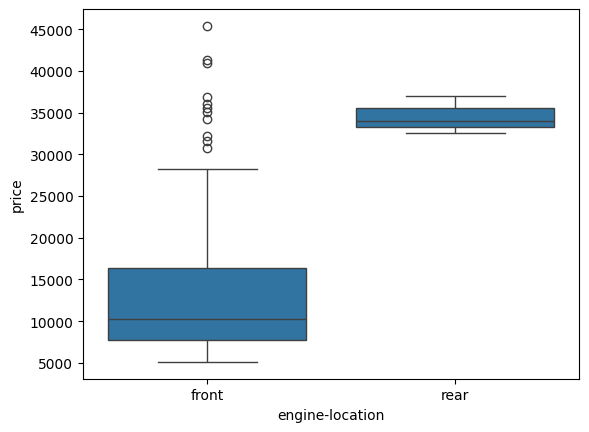

In [20]:
sns.boxplot(x="engine-location", y="price", data=df)

<Axes: xlabel='drive-wheels', ylabel='price'>

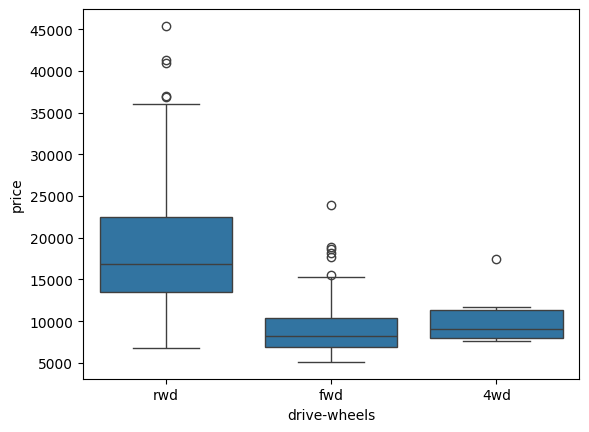

In [21]:
sns.boxplot(x="drive-wheels", y="price", data=df)

📘 15. Using the dataset `df`, perform the following steps:

1. Create a new DataFrame that contains **only** the columns:
    
    - `drive-wheels`
        
    - `body-style`
        
    - `price`
        
2. Group the data by:
    
    - `drive-wheels`
        
    - `body-style`
        
3. For each combination of drive wheels and body style, calculate the **average price**.
    
4. Make sure that:
    
    - The grouping variables remain as **regular columns** (not the index).
        
    - The result is displayed as a DataFrame.
        
5. Display the final grouped table.

🗒 Expected output structure

| drive-wheels | body-style | price    |
| ------------ | ---------- | -------- |
| fwd          | sedan      | 9811.8   |
| rwd          | hatchback  | 14337.78 |
| 4wd          | wagon      | 9095.75  |
| ...          | ...        | ...      |

<details><summary>Solution</summary>

```python
df_aux_pivot = df[['drive-wheels','body-style','price']]
pivtab_1 = df_aux_pivot.groupby(['drive-wheels','body-style'],as_index=False).mean()
pivtab_1
```

</details>

In [22]:
df_aux_pivot = df[['drive-wheels','body-style','price']]
pivtab_1 = df_aux_pivot.groupby(['drive-wheels','body-style'],as_index=False).mean()
pivtab_1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


📘 16. Using the DataFrame `pivtab_1` (which contains the average `price` for each combination of `drive-wheels` and `body-style`):

1. Transform the DataFrame into a **pivot table** where:
    
    - Rows (`index`) are `drive-wheels`
        
    - Columns (`columns`) are `body-style`
        
    - The values are the `price`
        
2. Replace any missing values in the pivot table with **0**.
    
3. Display the resulting pivot table.

✅ Expected output structure
| drive-wheels | convertible | hardtop | hatchback | sedan | wagon |
| ------------ | ----------- | ------- | --------- | ----- | ----- |
| 4wd          | 0           | 0       | 7603      | 12647 | 9095  |
| fwd          | 11595       | 8249    | 8396      | 9811  | 9997  |
| rwd          | 23949       | 24203   | 14338     | 21712 | 16994 |

<details><summary>Solution</summary>

```python
grouped_pivot = pivtab_1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot
```

</details>

In [23]:
grouped_pivot = pivtab_1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

# Correlation (technical)

📘 17. Imports only the `stats` module from `scipy` so you can use it in your code.

<details><summary>🤓 What are `scipy` and `stats`?</summary>

- **`scipy`** → a big Python library for scientific and numerical computing
    
- **`stats`** → a **submodule** of `scipy` that contains **statistical functions**

</details>

<details><summary>🤓 Why not just `import scipy`?</summary>

If you did:
```python
import scipy
```

- You would need to write `scipy.stats.ttest_ind(...)` every time
    
- By importing `stats` directly, you can write `stats.ttest_ind(...)`, which is shorter and cleaner.

</details>

<details><summary>Solution</summary>

```python
from scipy import stats
```

</details>

In [24]:
from scipy import stats

📘 18. Using the dataset `df`, perform the following steps:

1. Use the `pearsonr()` function from `scipy.stats` to calculate the **Pearson correlation coefficient** and **p-value** between:
    
    - `city-mpg` (independent variable)
        
    - `price` (dependent variable)
        
2. Based on the p-value and the correlation coefficient, write a short **conclusion** addressing:
    
    - Whether the correlation is **statistically significant**
        
    - The **direction** of the relationship (positive or negative)
        
    - The **strength** of the relationship (weak, moderate, strong)

In [25]:
pearson_coef, p_value = stats.pearsonr(df['city-mpg'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef.round(2), " with a P-value of P = ", p_value.round(4))

The Pearson Correlation Coefficient is -0.69  with a P-value of P =  0.0


📘 19. Using the dataset `df`, perform the following tasks:

1. Select the numerical variables listed in `corr_test`.
    
2. For each variable, compute the **Pearson correlation coefficient** and the corresponding **p-value** with respect to `price`, using `stats.pearsonr()`.
    
3. Store the results in a **pandas DataFrame** with the following columns:
    
    - `Variable`
        
    - `Pearson Coefficient`
        
    - `P-Value`
        
4. Sort the DataFrame by the **Pearson Coefficient** in **descending order**.
    
5. Display the final table.

✅ Expected outcome

||Variable|Pearson Coefficient|P-Value|
|---|---|---|---|
|6|engine-size|0.872335|9.265492e-64|
|5|curb-weight|0.834415|2.189577e-53|
|2|horsepower|0.809575|6.369057e-48|
|4|width|0.751265|9.200336e-38|
|3|length|0.690628|8.016477e-30|
|1|wheel-base|0.584642|8.076488e-20|
|7|bore|0.543155|8.049189e-17|
|0|city-mpg|-0.686571|2.321132e-29|


<details><summary>Solution</summary>

```python
corr_test = ['city-mpg','wheel-base','horsepower','length','width','curb-weight','engine-size','bore']

person_list = []
p_list = []

for i in corr_test:
  temp = stats.pearsonr(df[i], df['price'])
  #print(i, temp[0].round(2))
  person_list.append(temp[0])
  p_list.append(temp[1])

df_corr = pd.DataFrame({
    'Variable': corr_test,
    'Pearson Coefficient': person_list,
    'P-Value': p_list
})

df_corr.sort_values(by='Pearson Coefficient', ascending=False)
```

</details>

In [26]:
corr_test = ['city-mpg','wheel-base','horsepower','length','width','curb-weight','engine-size','bore']

person_list = []
p_list = []

for i in corr_test:
  temp = stats.pearsonr(df[i], df['price'])
  #print(i, temp[0].round(2))
  person_list.append(temp[0])
  p_list.append(temp[1])

df_corr = pd.DataFrame({
    'Variable': corr_test,
    'Pearson Coefficient': person_list,
    'P-Value': p_list
})

df_corr.sort_values(by='Pearson Coefficient', ascending=False)

,Variable,Pearson Coefficient,P-Value
6,engine-size,0.872335,9.265492e-64
5,curb-weight,0.834415,2.189577e-53
2,horsepower,0.809681,6.058445e-48
4,width,0.751265,9.200336e-38
3,length,0.690628,8.016477e-30
1,wheel-base,0.584642,8.076488e-20
7,bore,0.543154,8.051209e-17
0,city-mpg,-0.686571,2.321132e-29


# ANOVA

<details><summary>🤓 ANOVA Recap </summary>

**Analysis of Variance (ANOVA)** is a method used to check whether the **average values** of a variable (for example, price) are **different across groups** (such as product categories).

ANOVA produces two key results:

- **F-test score**: Measures how different the group averages are from each other. A **larger value** means the groups differ more.
    
- **P-value**: Tells us whether the observed differences are **statistically meaningful** or likely due to chance.
    

If the variable we analyze has a strong relationship with price, ANOVA will typically show a **high F-test score** and a **low p-value**.

</details>

📘 20. Determine whether the average car price differs significantly between cars with front-wheel drive fwd, rwd and 4wd.

1. **Create three separate datasets** that contain the car prices for each drive-wheel type:
    
    - One for `fwd`
        
    - One for `rwd`
        
    - One for `4wd`
        
2. **Apply a one-way ANOVA test** to compare the average prices across the three groups.
    
3. **Print the F-statistic and the p-value** returned by the ANOVA test.

<details><summary>Solution</summary>

```python
fwd_prices = df[df['drive-wheels'] == 'fwd']['price']
rwd_prices = df[df['drive-wheels'] == 'rwd']['price']
fourwd_prices = df[df['drive-wheels'] == '4wd']['price']

f_val, p_val = stats.f_oneway(fwd_prices, rwd_prices, fourwd_prices)

print( "ANOVA results: F=", f_val, ", P =", p_val )
```

</details>


In [27]:
fwd_prices = df[df['drive-wheels'] == 'fwd']['price']
rwd_prices = df[df['drive-wheels'] == 'rwd']['price']
fourwd_prices = df[df['drive-wheels'] == '4wd']['price']

f_val, p_val = stats.f_oneway(fwd_prices, rwd_prices, fourwd_prices)

print( "ANOVA results: F=", f_val, ", P =", p_val )

ANOVA results: F= 67.954065007804 , P = 3.394544357715048e-23


📘 21. Using the three price datasets you created previously (`fwd_prices`, `rwd_prices`, `fourwd_prices`), perform **pairwise ANOVA tests** for each combination of drive-wheel types.

<details><summary>Solution</summary>

```python
f_val, p_val = stats.f_oneway(fwd_prices, rwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )

f_val, p_val = stats.f_oneway(fwd_prices, fourwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )

f_val, p_val = stats.f_oneway(rwd_prices, fourwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )
```

</details>




In [28]:
f_val, p_val = stats.f_oneway(fwd_prices, rwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )

f_val, p_val = stats.f_oneway(fwd_prices, fourwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )

f_val, p_val = stats.f_oneway(rwd_prices, fourwd_prices)
print( "ANOVA results: F=", f_val, ", P =", p_val )

ANOVA results: F= 130.55331609591107 , P = 2.2355306355678244e-23
ANOVA results: F= 0.6654657502523033 , P = 0.41620116697846155
ANOVA results: F= 8.580681368924756 , P = 0.004411492211225331


📘 22. Based on the ANOVA results (three groups and pairwise), provide an intepretation of the results.


<details><summary>Solution</summary>

Drive-wheel type affects car price, but not all pairwise comparisons are significant.

- Front-wheel (`fwd`) and rear-wheel (`rwd`) cars differ strongly in price.
    
- Rear-wheel (`rwd`) and four-wheel (`4wd`) cars also differ.
    
- Front-wheel (`fwd`) and four-wheel (`4wd`) cars **do not have a significant price difference**.

</details>


The overall ANOVA shows that average car prices differ significantly across `fwd`, `rwd`, and `4wd` cars. Pairwise tests reveal that `fwd` and `rwd` cars, as well as `rwd` and `4wd` cars, have significantly different prices, while `fwd` and `4wd` cars do not differ significantly in price.